In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
import arviz as az
from astropy.io import fits
from astropy.table import Table
import jax
import jax.numpy as jnp
import jax.random as random
import matplotlib.pyplot as plt
import numpy as np
import numpy.random as npr
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
import pandas as pd
from pathlib import Path
import seaborn as sns

numpyro.set_host_device_count(10)

In [3]:
fits_file = Path('..') / "data" / "J0740_merged_phase_0.25-3keV.fits.gz"
event_data = Table.read(fits_file, hdu=1)
names = [name for name in event_data.colnames if len(event_data[name].shape) <= 1]
event_data = event_data[names].to_pandas()

event_data["PI_INDEX"] = event_data.PI - event_data.PI.min()

segment_data = Table.read(fits_file, hdu=3)
segment_data = segment_data.to_pandas()

In [103]:
event_data

,TIME,RAWX,RAWY,PHA,PHA_FAST,DET_ID,DEADTIME,TICK,MPU_A_TEMP,MPU_UNDER_COUNT,PI_FAST,PI,PI_RATIO,PULSE_PHASE,BARY_TIME,PI_INDEX
0,1.490230e+08,5,0,559,<NA>,16,0.000015,3877143253249,35.699532,6,<NA>,56,NaN,0.092807,58382.803025,31
1,1.490230e+08,3,5,424,<NA>,41,0.000015,3869559199763,34.533439,6,<NA>,47,NaN,0.407027,58382.803033,22
2,1.490230e+08,7,5,410,<NA>,1,0.000015,3877000089253,35.169490,5,<NA>,37,NaN,0.960653,58382.803043,12
3,1.490230e+08,2,3,587,530,53,0.000023,3868268002109,33.579363,5,91,81,0.890110,0.510469,58382.803058,56
4,1.490230e+08,1,5,486,<NA>,62,0.000015,3865281153742,33.473355,7,<NA>,57,NaN,0.673380,58382.803066,32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3738800,3.582153e+08,4,6,440,<NA>,30,0.000018,93747598704992,41.105962,9,<NA>,55,NaN,0.381621,60804.008983,30
3738801,3.582153e+08,6,6,467,<NA>,10,0.000016,93761305700915,40.045878,16,<NA>,87,NaN,0.819231,60804.008992,62
3738802,3.582153e+08,6,1,462,394,15,0.000022,93761360017658,40.045878,8,48,53,1.104167,0.200493,60804.009016,28
3738803,3.582153e+08,1,2,509,<NA>,54,0.000016,93745338306772,37.289658,8,<NA>,59,NaN,0.168680,60804.009028,34


In [4]:
segment_indices = np.digitize(event_data.TIME.values, segment_data.START.values)-1
segment_Ts = segment_data['STOP'].values - segment_data['START'].values

segment_indices = segment_indices.astype(int)

Let's cut out any intervals that have zero counts (these seem to cause problems), and don't contribute any information about the variable intensity anyway.

In [98]:
counts = np.bincount(segment_indices)
zero_counts = np.where(counts == 0)
nonzero_counts = np.where(counts > 0)

segment_data = segment_data.iloc[nonzero_counts]

segment_indices = np.digitize(event_data.TIME.values, segment_data.START.values)-1
segment_Ts = segment_data['STOP'].values - segment_data['START'].values

segment_indices = segment_indices.astype(int)

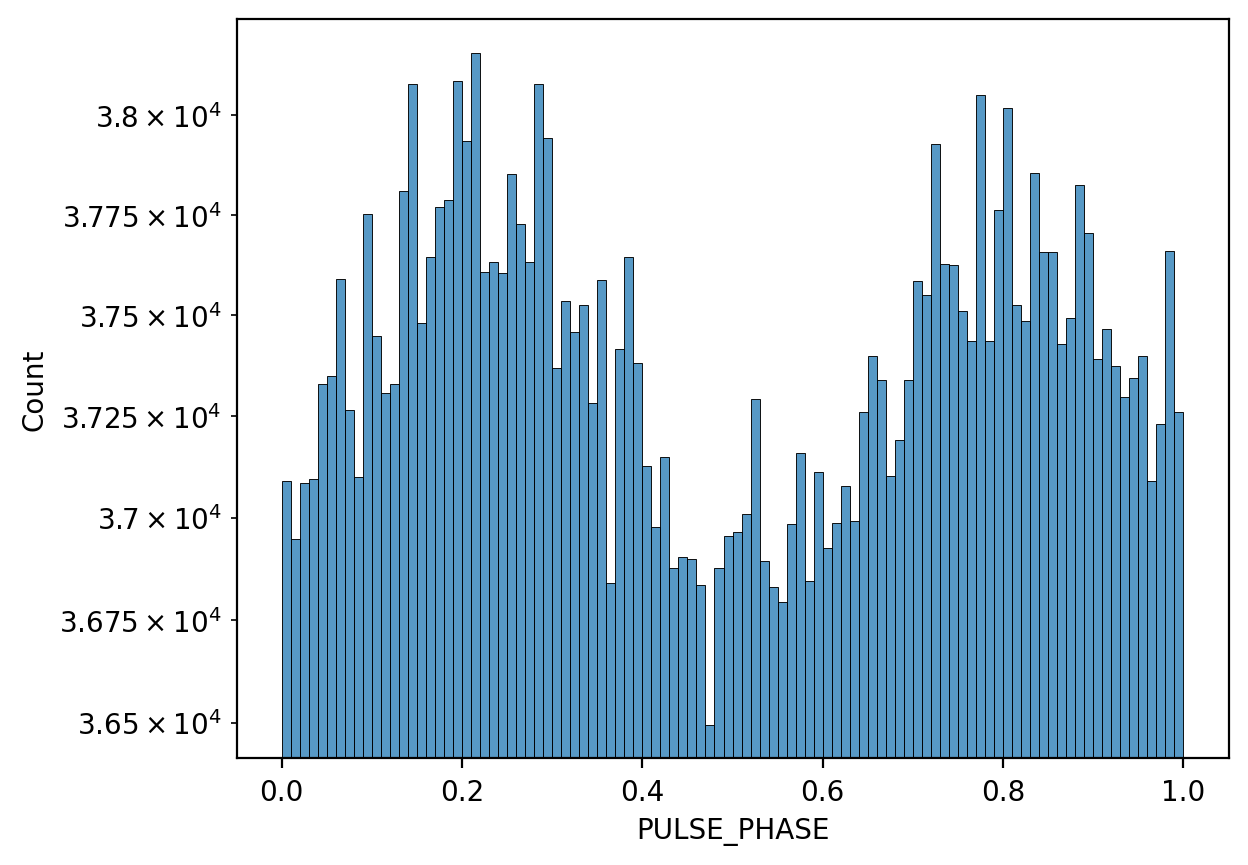

In [99]:
sns.histplot(event_data['PULSE_PHASE'], bins=100)
plt.yscale('log')

In [100]:
def model(phases, pi_indices, segment_indices, segment_Ts, nfourier, est_bg, est_bg_uncert, est_bg_spec, est_bg_spec_uncert, variability_fraction=0.1, lc_phases=None):
    npi = np.max(pi_indices) + 1

    phases, pi_indices, segment_indices, segment_Ts = map(jnp.asarray, (phases, pi_indices, segment_indices, segment_Ts))

    T = jnp.sum(segment_Ts)

    M = []
    for k in range(1, nfourier + 1):
        M.append(jnp.sin(2 * jnp.pi * k * phases))
        M.append(jnp.cos(2 * jnp.pi * k * phases))
    M = jnp.column_stack(M)

    mean_rate = phases.shape[0] / T

    est_log_bg_uncert = est_bg_uncert / est_bg
    est_log_bg_spec_uncert = est_bg_spec_uncert / est_bg_spec

    log_bg_dspec = numpyro.sample('log_bg_dspec', dist.Normal(0, 4), sample_shape=(npi,))
    bg_spec_unnorm = jnp.exp(log_bg_dspec * est_log_bg_spec_uncert) * est_bg_spec
    bg_spec = numpyro.deterministic('bg_spec', bg_spec_unnorm / jnp.sum(bg_spec_unnorm))
    fg_spec = numpyro.sample('fg_spec', dist.Dirichlet(np.ones(npi)))

    log_dbg = numpyro.sample('log_dbg', dist.Normal(0, 4), sample_shape=(segment_Ts.shape[0],))
    bg = numpyro.deterministic('bg', jnp.exp(log_dbg * est_log_bg_uncert)*est_bg)

    dbeta_scale = numpyro.sample('dbeta_scale', dist.Exponential(1.0))
    dbeta_unit = numpyro.sample('dbeta', dist.Normal(0, 1), sample_shape=(2*nfourier,))
    beta = numpyro.deterministic('beta', dbeta_unit * dbeta_scale * mean_rate * variability_fraction)

    total_exp_counts = jnp.sum(bg * segment_Ts) # The oscillatory component has zero mean

    rate_at_events = bg[segment_indices]*bg_spec[pi_indices] + jnp.matmul(M, beta)*fg_spec[pi_indices]
    log_rate_at_events = jnp.log(rate_at_events)

    numpyro.factor('log_likelihood', jax.lax.cond(jnp.all(rate_at_events > 0),
                                                  lambda _: jnp.sum(log_rate_at_events) - total_exp_counts,
                                                  lambda _: -jnp.inf,
                                                  operand=None))
    
    if lc_phases is not None:
        M_lc = []
        for k in range(1, nfourier + 1):
            M_lc.append(jnp.sin(2 * jnp.pi * k * lc_phases))
            M_lc.append(jnp.cos(2 * jnp.pi * k * lc_phases))
        M_lc = jnp.column_stack(M_lc)

        lc_rate = jnp.matmul(M_lc, beta)
        numpyro.deterministic('lc', lc_rate)

In [101]:
nfourier = 5
nseg = segment_Ts.shape[0]

sel = segment_indices < nseg
phs = event_data.PULSE_PHASE.values[sel]
pii = event_data.PI_INDEX.values[sel]
si = segment_indices[sel]
Ts = segment_Ts[:nseg]

seg_counts = np.bincount(si) + 0.5
spec_counts = np.bincount(pii) + 0.5

mean_rate = phs.shape[0] / jnp.sum(Ts)
bg_est = seg_counts / Ts
bg_est_uncert = np.sqrt(seg_counts) / Ts

bg_spec_est = spec_counts / np.sum(spec_counts)
bg_spec_est_uncert = np.sqrt(spec_counts) / np.sum(spec_counts)

init = {
    'log_dbg': jnp.zeros(nseg),
    'dbeta': jnp.zeros(2*nfourier)
}

data_args = (phs, pii, si, Ts, 5, bg_est, bg_est_uncert, bg_spec_est, bg_spec_est_uncert)
data_kwargs = dict(variability_fraction=0.01)

nuts_kernel = NUTS(model, init_strategy=numpyro.infer.init_to_value(values=init))
mcmc = MCMC(nuts_kernel, num_warmup=1000, num_samples=1000)
rng_key = random.key(npr.randint(1<<32))
mcmc.run(rng_key, *data_args, **data_kwargs)

warmup:   0%|          | 8/2000 [02:08<8:54:12, 16.09s/it, 1023 steps of size 5.82e-06. acc. prob=0.23] 


KeyboardInterrupt: 

In [ ]:
lc_phases = jnp.linspace(0, 1, 100)
pred = numpyro.infer.Predictive(model, mcmc.get_samples())(random.key(npr.randint(1<<32)), *data_args, lc_phases=lc_phases, **data_kwargs)

In [ ]:
trace = az.from_numpyro(mcmc, posterior_predictive=pred)

In [ ]:
trace.log_likelihood.log_likelihood.mean(dim=['draw'])

<xarray.DataArray 'log_likelihood' (chain: 1)> Size: 4B
array([-4.0760595e+06], dtype=float32)
Coordinates:
  * chain    (chain) int64 8B 0

In [ ]:
def find_good_chain_index(trace):
    mean_logls = trace.log_likelihood.log_likelihood.mean(dim='draw')
    se_mean_logls = trace.log_likelihood.log_likelihood.std(dim='draw') / jnp.sqrt(len(trace.log_likelihood.draw)) 

    max_mean_logl = jnp.max(jnp.asarray(mean_logls))

    good_sel = list(jnp.abs(jnp.asarray((max_mean_logl - mean_logls) / se_mean_logls)) < 10) # Relaxed---10 standard errors away from the maximum

    return trace.posterior.chain[good_sel]


In [ ]:
good_chains = find_good_chain_index(trace)
bad_trace = trace
trace = trace.sel(chain=good_chains)

array([[<Axes: title={'center': 'beta'}>,
        <Axes: title={'center': 'beta'}>],
       [<Axes: title={'center': 'bg'}>, <Axes: title={'center': 'bg'}>],
       [<Axes: title={'center': 'bg_spec'}>,
        <Axes: title={'center': 'bg_spec'}>],
       [<Axes: title={'center': 'dbeta'}>,
        <Axes: title={'center': 'dbeta'}>],
       [<Axes: title={'center': 'dbeta_scale'}>,
        <Axes: title={'center': 'dbeta_scale'}>],
       [<Axes: title={'center': 'fg_spec'}>,
        <Axes: title={'center': 'fg_spec'}>],
       [<Axes: title={'center': 'log_bg_dspec'}>,
        <Axes: title={'center': 'log_bg_dspec'}>],
       [<Axes: title={'center': 'log_dbg'}>,
        <Axes: title={'center': 'log_dbg'}>]], dtype=object)

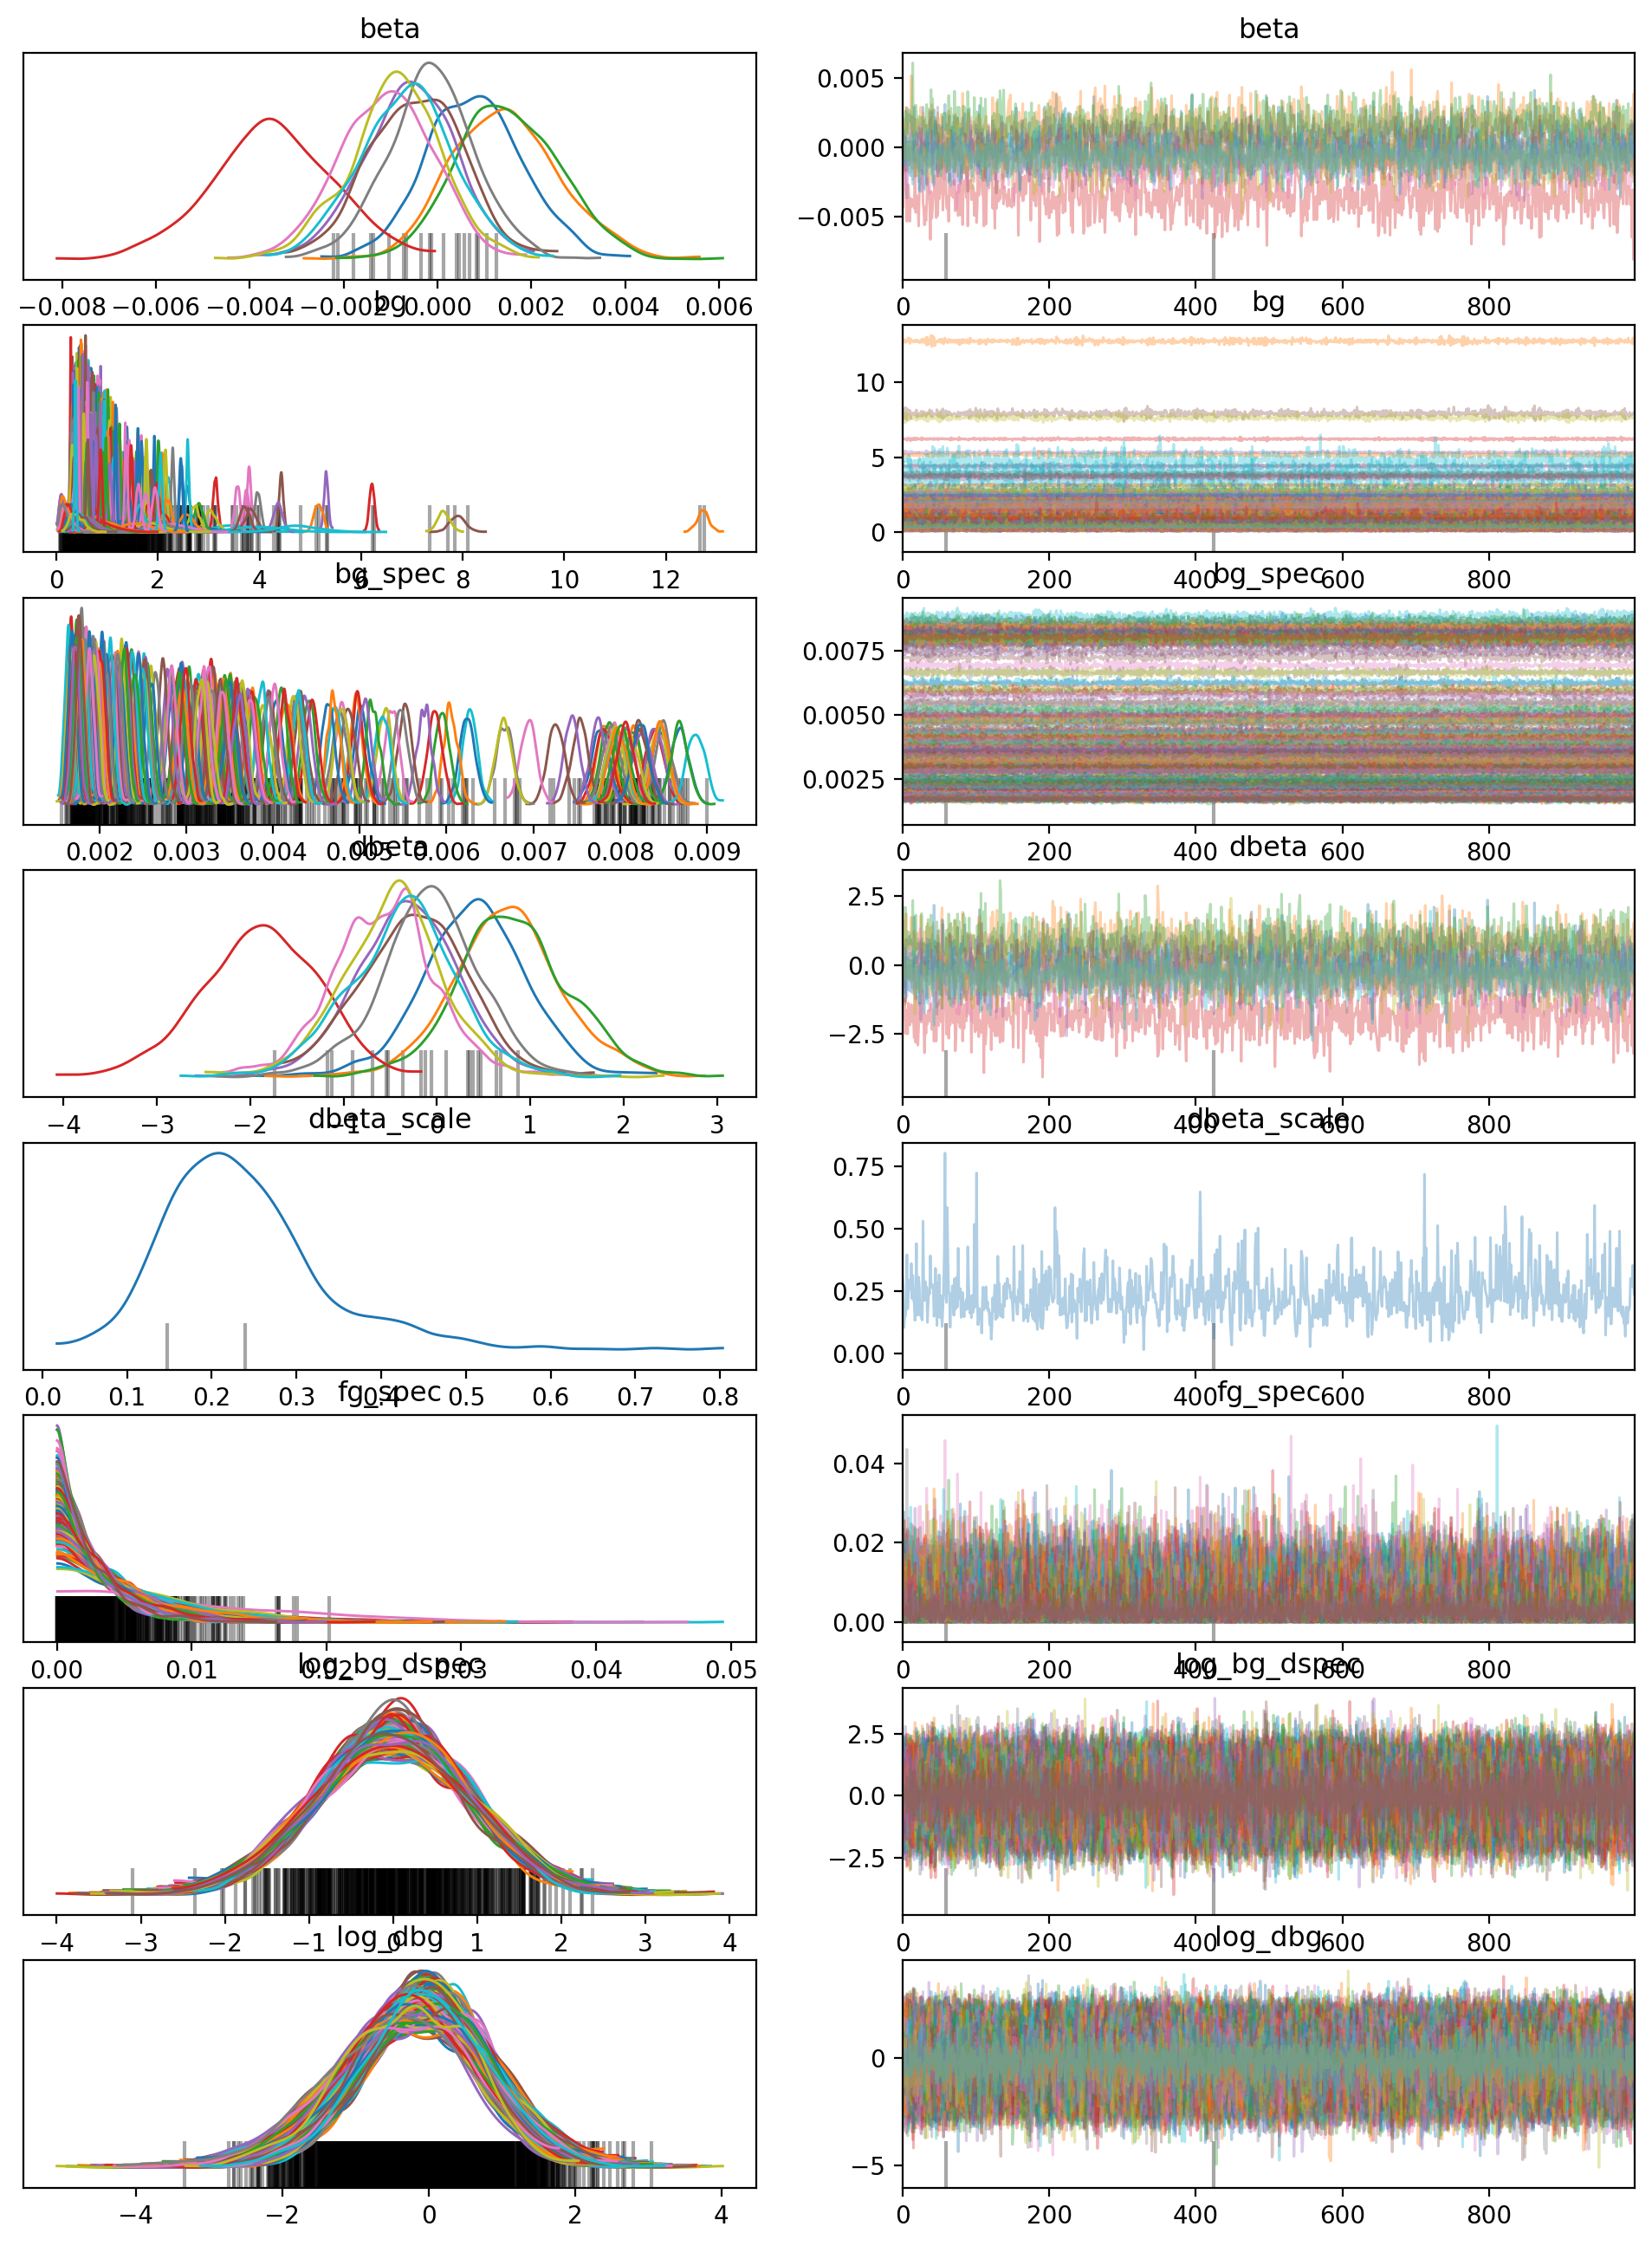

In [ ]:
az.plot_trace(trace)

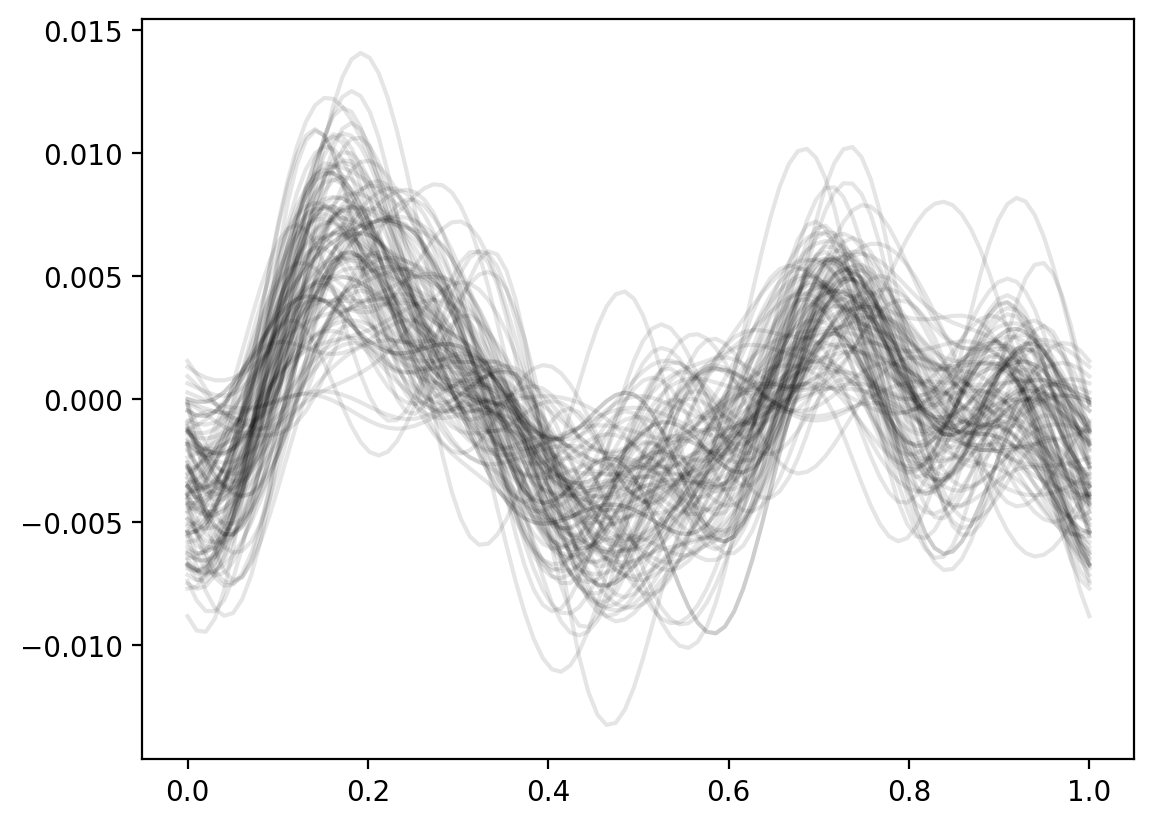

In [ ]:
for _ in range(100):
    c = npr.choice(trace.posterior.chain)
    d = npr.choice(trace.posterior.draw)
    lc_rate = trace.posterior_predictive.lc.sel(chain=c,draw=d)
    plt.plot(lc_phases, lc_rate, color='k', alpha=0.1)

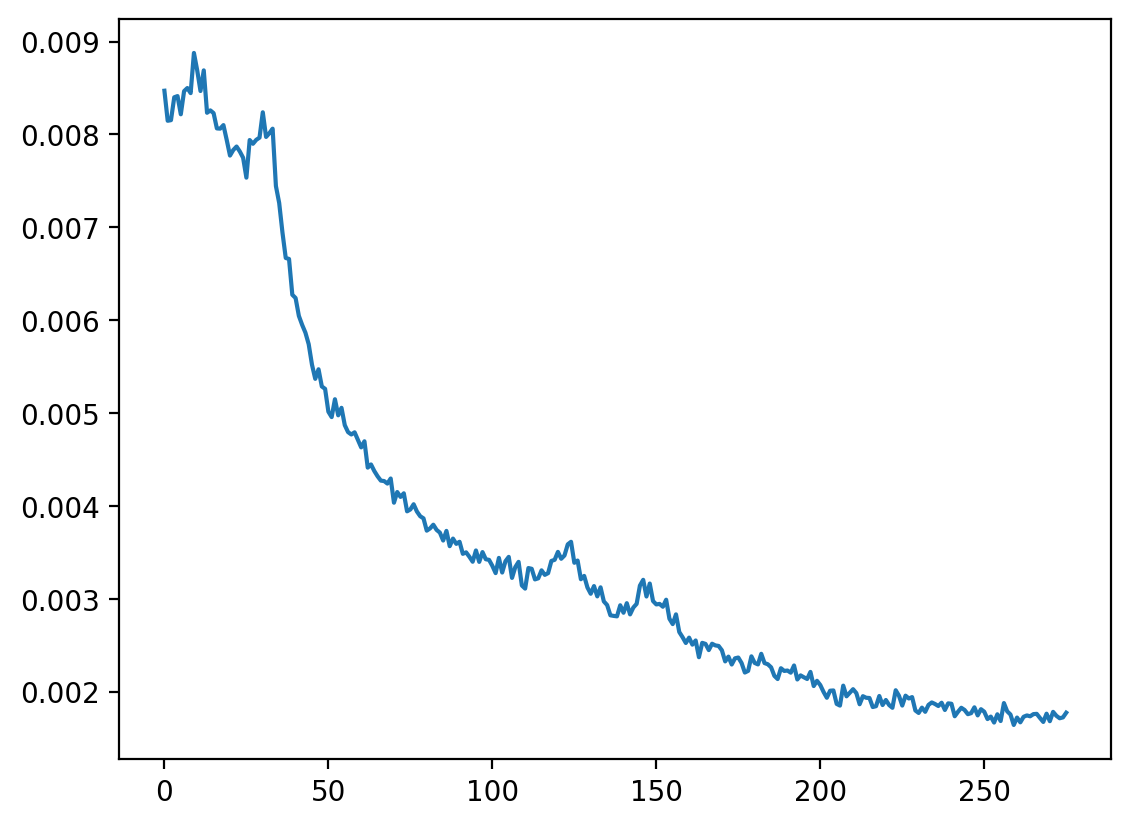

In [ ]:
plt.plot(trace.posterior.bg_spec.mean(dim=('chain','draw')))

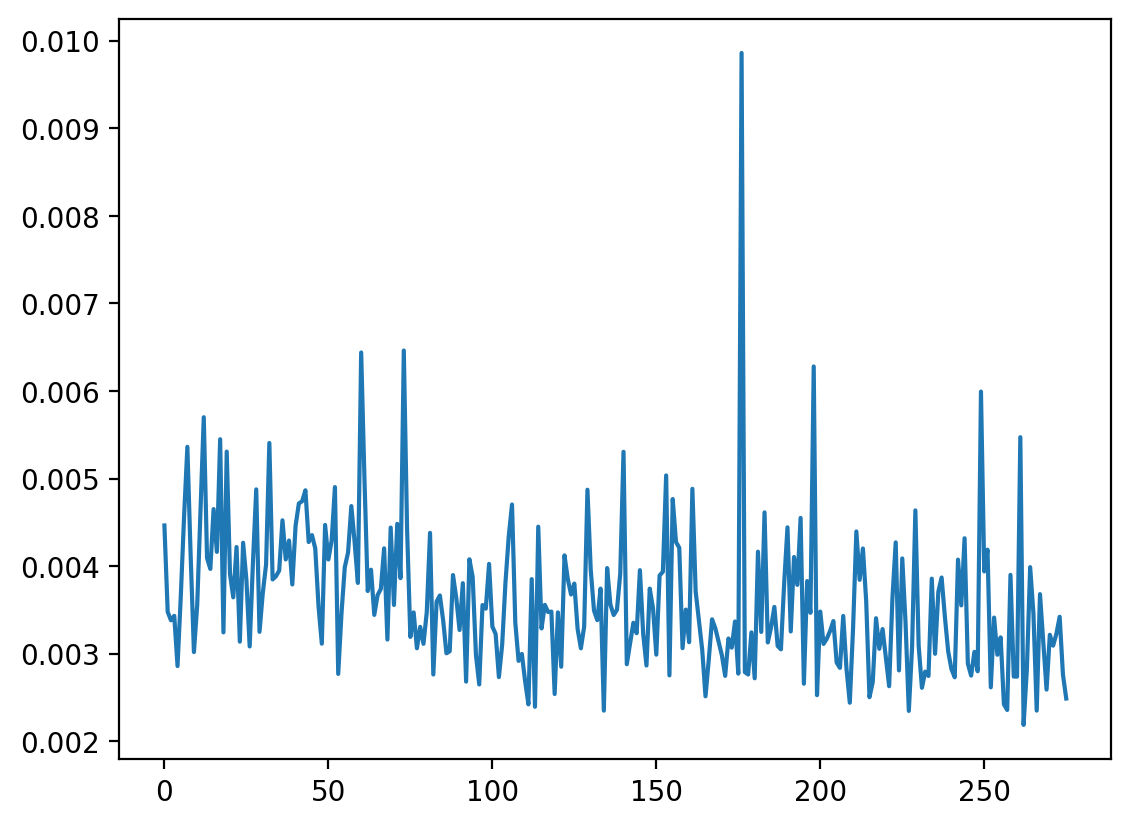

In [ ]:
plt.plot(trace.posterior.fg_spec.mean(dim=('chain','draw')))

array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

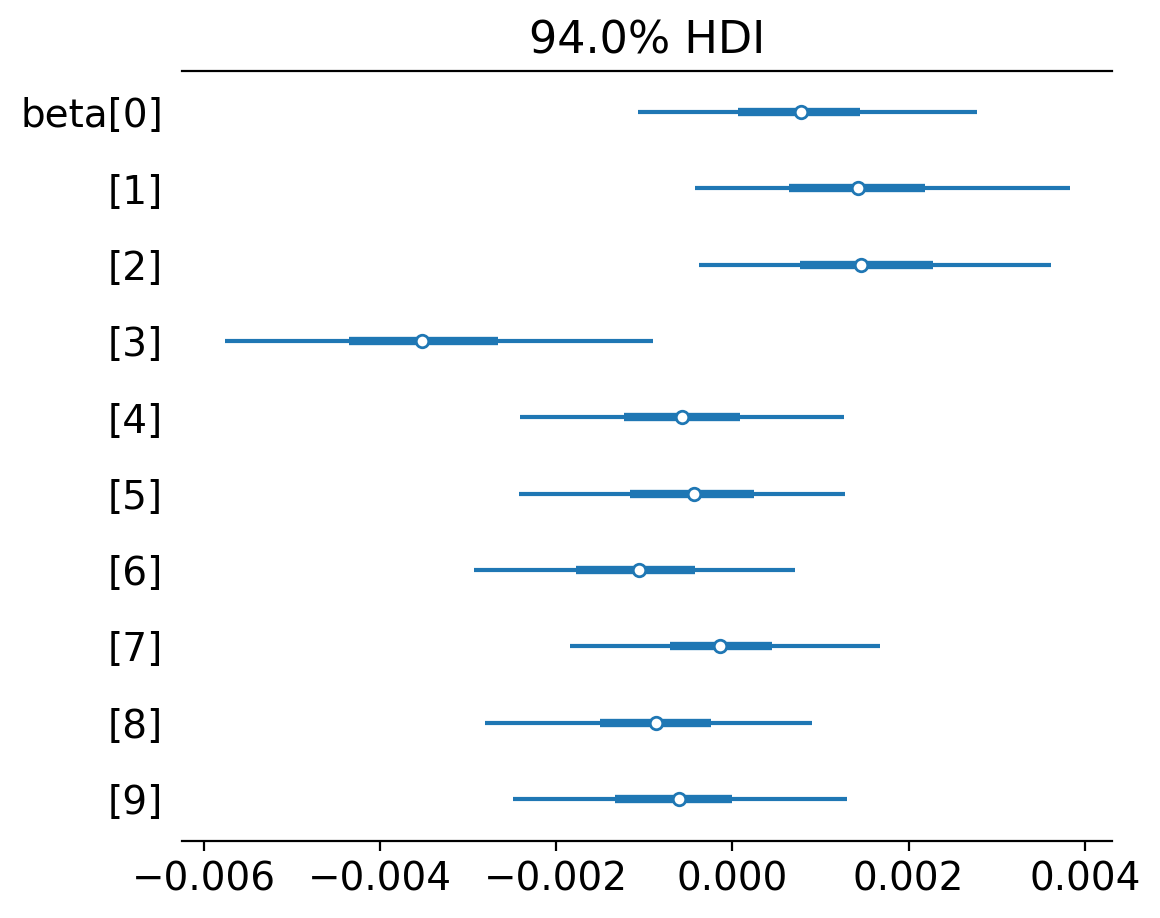

In [ ]:
az.plot_forest(trace, var_names=['beta'])

In [ ]:
az.to_netcdf(trace, Path('..', 'data', 'J0740_trace.nc'))

PosixPath('../data/J0740_trace.nc')